Importing Libraries

In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.model_selection import train_test_split
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate

Reproducibility

In [2]:
tf.random.set_seed(42)
np.random.seed(42)

Image Preprocessing

In [3]:
folder_path = "Face_Human"
images = []

for file in os.listdir(folder_path):
    img_path = os.path.join(folder_path, file)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # grayscale
    
    if img is None:
        continue 

    img = cv2.resize(img, (128, 128))               # autoencoder input size
    img = img.astype('float32') / 255.0             # normalize 0-1
    img = np.expand_dims(img, axis=-1)              # shape (128,128,1)
    images.append(img)

images = np.array(images)
print("Total images loaded:", images.shape)

Total images loaded: (2070, 128, 128, 1)


Train/Test Split

In [4]:
X_train,X_test = train_test_split(images,test_size=0.2,random_state=42)
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (1656, 128, 128, 1)
Test set: (414, 128, 128, 1)


Noise Function

In [5]:
def add_noise(imgs, mean=0.0, stddev=0.15):
    noise = np.random.normal(mean, stddev, imgs.shape)
    noisy_imgs = imgs + noise
    noisy_imgs = np.clip(noisy_imgs, 0.0, 1.0)
    return noisy_imgs

x_train_noisy = add_noise(X_train, mean=0.0, stddev=0.15)
x_test_noisy  = add_noise(X_test, mean=0.0, stddev=0.15)

Image Visualize

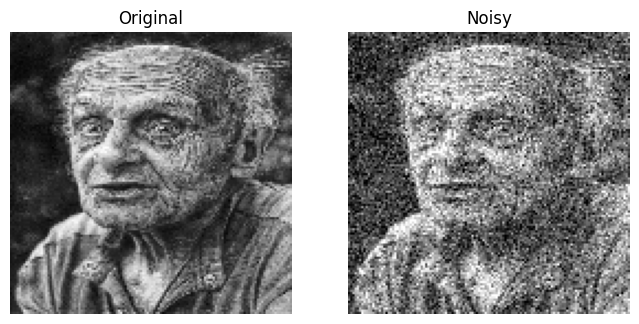

In [6]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(X_train[3].squeeze(), cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(x_train_noisy[3].squeeze(), cmap="gray")
plt.title("Noisy")
plt.axis("off")

plt.show()

Build Model Architectural

In [7]:
def build_improved_unet(input_shape=(128, 128, 1)):
    inputs = Input(shape=input_shape)
    
    # Encoder
    c1 = Conv2D(32, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(inputs)
    c1 = Conv2D(32, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(c1)
    p1 = MaxPooling2D((2, 2))(c1)
    
    c2 = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(p1)
    c2 = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(c2)
    p2 = MaxPooling2D((2, 2))(c2)
    
    c3 = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(p2)
    c3 = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(c3)
    p3 = MaxPooling2D((2, 2))(c3)
    
    c4 = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(p3)
    c4 = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(c4)
    p4 = MaxPooling2D((2, 2))(c4)
    
    # Bottleneck
    c5 = Conv2D(512, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(p4)
    c5 = Conv2D(512, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(c5)
    
    # Decoder
    u6 = UpSampling2D((2, 2))(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(u6)
    c6 = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(c6)
    
    u7 = UpSampling2D((2, 2))(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(u7)
    c7 = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(c7)
    
    u8 = UpSampling2D((2, 2))(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(u8)
    c8 = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(c8)
    
    u9 = UpSampling2D((2, 2))(c8)
    u9 = concatenate([u9, c1])
    c9 = Conv2D(32, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(u9)
    c9 = Conv2D(32, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(c9)
    
    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c9)
    
    model = keras.Model(inputs=[inputs], outputs=[outputs], name="Improved_UNet")
    return model

model = build_improved_unet()
model.summary()

Model: "Improved_UNet"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 128, 128, 1  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 128, 128, 32  320         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 conv2d_1 (Conv2D)              (None, 128, 128, 32  9248        ['conv2d[0][0]']                 
                                )                                                     

Model Compile

In [8]:
# Mixed Loss: MSE + MAE for sharper results
def combine_loss(y_true, y_pred):
    mse = tf.keras.losses.MSE(y_true, y_pred)
    mae = tf.keras.losses.MAE(y_true, y_pred)
    return 0.7 * mse + 0.3 * mae

In [9]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=combine_loss,
    metrics=['mse', 'mae']
)

Callbacks

In [10]:
callbacks = [
    ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5, 
        patience=5, 
        min_lr=1e-7, 
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss', 
        patience=10, 
        restore_best_weights=True, 
        verbose=1),
    # ModelCheckpoint(
    #     filepath="denoising_autoencoder.keras",
    #     monitor="val_loss",      # Metric to monitor
    #     verbose=1,               # Log to console
    #     save_best_only=True,     # Only save when val_loss improves
    #     mode="min",              # Minimize loss
    #     save_weights_only=False, # Save entire model (False) or only weights (True)
    #     save_freq="epoch"        # Save every epoch
    # )
     ModelCheckpoint(
        filepath="best_denoising_unet.keras",
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=False, 
        mode="min",
        save_freq="epoch",
        verbose=1
    )
]

Model Fit Train

In [11]:
history = model.fit(
    x_train_noisy, X_train,
    epochs=100,
    batch_size=32,
    validation_data=(x_test_noisy, X_test),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
52/52 [==============================] - ETA: 0s - loss: 0.0712 - mse: 0.0416 - mae: 0.1401
Epoch 1: val_loss improved from inf to 0.02411, saving model to best_denoising_unet.keras
52/52 [==============================] - 12s 170ms/step - loss: 0.0712 - mse: 0.0416 - mae: 0.1401 - val_loss: 0.0241 - val_mse: 0.0079 - val_mae: 0.0620 - lr: 0.0010
Epoch 2/100
52/52 [==============================] - ETA: 0s - loss: 0.0200 - mse: 0.0058 - mae: 0.0532
Epoch 2: val_loss improved from 0.02411 to 0.01713, saving model to best_denoising_unet.keras
52/52 [==============================] - 6s 108ms/step - loss: 0.0200 - mse: 0.0058 - mae: 0.0532 - val_loss: 0.0171 - val_mse: 0.0045 - val_mae: 0.0466 - lr: 0.0010
Epoch 3/100
52/52 [==============================] - ETA: 0s - loss: 0.0168 - mse: 0.0043 - mae: 0.0458
Epoch 3: val_loss improved from 0.01713 to 0.01527, saving model to best_denoising_unet.keras
52/52 [==============================] - 6s 108ms/step - loss: 0.0168 - mse: 

Predict

In [12]:
reconstructed = model.predict(x_test_noisy)

13/13 [==============================] - 1s 42ms/step


Model Save

Visualization

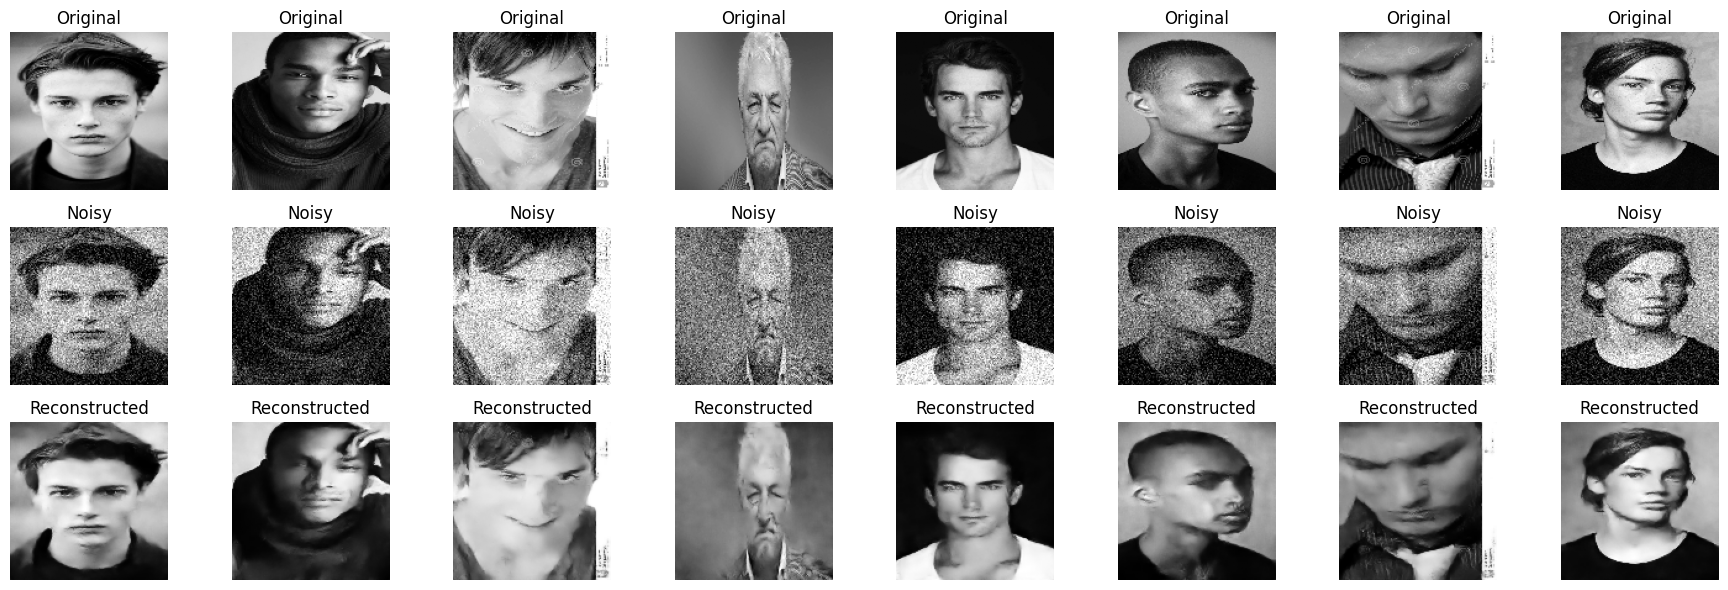

In [13]:
n = 8
plt.figure(figsize=(18,6))

for i in range(n):

    # Original
    plt.subplot(3, n, i+1)
    plt.imshow(X_test[i].squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Noisy
    plt.subplot(3, n, i+1+n)
    plt.imshow(x_test_noisy[i].squeeze(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    # Reconstructed
    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(reconstructed[i].squeeze(), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.savefig("final_results.png", dpi=150, bbox_inches='tight')
plt.show()

Training Plot

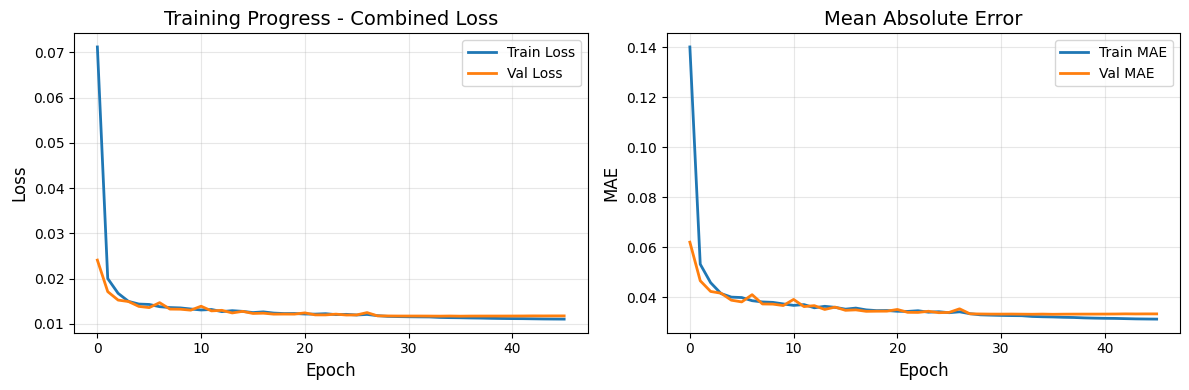

In [14]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss", linewidth=2)
plt.plot(history.history["val_loss"], label="Val Loss", linewidth=2)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.legend(fontsize=10)
plt.title("Training Progress - Combined Loss", fontsize=14)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history["mae"], label="Train MAE", linewidth=2)
plt.plot(history.history["val_mae"], label="Val MAE", linewidth=2)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("MAE", fontsize=12)
plt.legend(fontsize=10)
plt.title("Mean Absolute Error", fontsize=14)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_metrics.png", dpi=150, bbox_inches='tight')
plt.show()

Quality Metrics

In [15]:
psnr_scores = []
ssim_scores = []

for i in range(len(X_test)):
    original = X_test[i].squeeze()
    reconstructed_img = reconstructed[i].squeeze()

    psnr_val = psnr(original, reconstructed_img, data_range=1.0)
    ssim_val = ssim(original, reconstructed_img, data_range=1.0)

    psnr_scores.append(psnr_val)
    ssim_scores.append(ssim_val)

print(f"Average PSNR: {np.mean(psnr_scores):.2f} dB")
print(f"Average SSIM: {np.mean(ssim_scores):.4f}")
print(f"Std PSNR: {np.std(psnr_scores):.2f} dB")
print(f"Std SSIM: {np.std(ssim_scores):.4f}")
print(f"Min PSNR: {np.min(psnr_scores):.2f} dB")
print(f"Max PSNR: {np.max(psnr_scores):.2f} dB")

Average PSNR: 26.39 dB
Average SSIM: 0.7974
Std PSNR: 1.81 dB
Std SSIM: 0.0540
Min PSNR: 20.65 dB
Max PSNR: 30.44 dB
